# MCS Case Study 01 — AMP: Analysis notebook

This notebook analyzes **Case 01 (AMP)** under the **Minimal Community Standard (MCS)** artifact layout.

It assumes you already ran:
1. Dataset builder (Notebook 1)
2. Split pool generator (Notebook 2)
3. Embeddings (Sylphy script)
4. Training + predictions export (RF script v3)

**Main goal:** quantify **performance fragility** and **calibration variability** under minimal split changes.

Outputs are saved to `figures/` and `tables/` within the case directory.

In [14]:
# --- Config ---
from pathlib import Path

CASE_DIR = Path("../../demonstrative_applications/case_demo_01")  # adjust if needed
EXECUTIONS_DIR = CASE_DIR / "executions"

TARGET_COL = "Antimicrobial"
SEQ_COL = "sequence"

FIG_DIR = CASE_DIR / "figures" / "case01"
TAB_DIR = CASE_DIR / "tables" / "case01"
FIG_DIR.mkdir(parents=True, exist_ok=True)
TAB_DIR.mkdir(parents=True, exist_ok=True)

print("CASE_DIR:", CASE_DIR.resolve())
print("EXECUTIONS_DIR:", EXECUTIONS_DIR.resolve())

CASE_DIR: /home/david/Desktop/umag_projects/MinimalCommunityStandar_v0.1/demonstrative_applications/case_demo_01
EXECUTIONS_DIR: /home/david/Desktop/umag_projects/MinimalCommunityStandar_v0.1/demonstrative_applications/case_demo_01/executions


In [15]:
# --- Imports ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.calibration import calibration_curve

In [16]:
# --- Helpers ---
def latest_run_id(executions_dir: Path) -> str:
    runs = [p.name for p in executions_dir.iterdir() if p.is_dir()]
    if not runs:
        raise FileNotFoundError(f"No runs found in: {executions_dir}")
    return sorted(runs)[-1]

def load_summary(case_dir: Path, run_id: str) -> pd.DataFrame:
    p = case_dir / "executions" / run_id / "summary.csv"
    if not p.exists():
        raise FileNotFoundError(f"Missing summary.csv: {p}")
    return pd.read_csv(p)

def load_execution(case_dir: Path, run_id: str) -> dict:
    p = case_dir / "executions" / run_id / "execution.yaml"
    if not p.exists():
        raise FileNotFoundError(f"Missing execution.yaml: {p}")
    import yaml
    with open(p, "r", encoding="utf-8") as f:
        return yaml.safe_load(f)

def load_preds(schema_path: str, split: str = "test") -> pd.DataFrame:
    out_dir = Path(schema_path).parent
    p = out_dir / f"preds_{split}.csv"
    if not p.exists():
        raise FileNotFoundError(f"Missing predictions file: {p}")
    return pd.read_csv(p)

def ensure_columns(df: pd.DataFrame, cols, name: str) -> None:
    missing = [c for c in cols if c not in df.columns]
    if missing:
        raise ValueError(f"{name} missing columns: {missing}. Found: {list(df.columns)}")

## 1) Load the latest execution run

In [17]:
RUN_ID = latest_run_id(EXECUTIONS_DIR)
print("Using RUN_ID:", RUN_ID)

execution = load_execution(CASE_DIR, RUN_ID)
summary = load_summary(CASE_DIR, RUN_ID)

display(summary.head())
print("Rows:", len(summary))
print("Strategies:", summary["strategy"].unique())
print("Seeds:", sorted(summary["seed"].unique()))

Using RUN_ID: 20260125T185108Z


FileNotFoundError: Missing summary.csv: ../../demonstrative_applications/case_demo_01/executions/20260125T185108Z/summary.csv

In [5]:
# Save a copy of the summary for the case analysis bundle
summary_out = TAB_DIR / f"summary_{RUN_ID}.csv"
summary.to_csv(summary_out, index=False)
print("Saved:", summary_out)

Saved: ../../demonstrative_applications/case_demo_01/tables/case01/summary_20260125T182441Z.csv


## 2) Performance fragility: distribution across seeds

In [6]:
metrics = ["test_auprc", "test_auroc", "test_f1", "test_mcc"]
agg = summary.groupby(["strategy"])[metrics].agg(["mean", "std", "min", "max"])
display(agg)

agg_out = TAB_DIR / f"metrics_by_strategy_{RUN_ID}.csv"
agg.to_csv(agg_out)
print("Saved:", agg_out)

test_auprc                               test_auroc            \
               mean       std       min       max       mean       std   
strategy                                                                 
splits     0.896539  0.013564  0.863381  0.918419   0.917155  0.009369   

                               test_f1                                \
               min       max      mean       std       min       max   
strategy                                                               
splits    0.899197  0.933223  0.779753  0.018284  0.745714  0.819444   

          test_mcc                                
              mean       std       min       max  
strategy                                          
splits    0.678561  0.023994  0.626533  0.729505

Saved: ../../demonstrative_applications/case_demo_01/tables/case01/metrics_by_strategy_20260125T182441Z.csv


/tmp/ipykernel_65827/1714735931.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=labels, showfliers=True)


ValueError: Dimensions of labels and X must be compatible

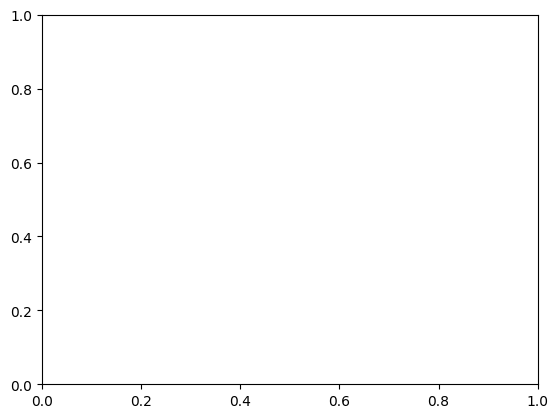

In [7]:
# Boxplot: AUPRC across strategies
labels = [s for s in ["random", "stratified"] if s in summary["strategy"].unique()]
data = [summary.loc[summary["strategy"] == s, "test_auprc"].to_numpy() for s in labels]

plt.figure()
plt.boxplot(data, labels=labels, showfliers=True)
plt.ylabel("Test AUPRC")
plt.title("Case 01 (AMP) — AUPRC fragility across seeds")
fig_path = FIG_DIR / f"auprc_boxplot_{RUN_ID}.png"
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()
print("Saved:", fig_path)

In [8]:
# Paired comparison plot (same seed, random vs stratified)
if set(["random", "stratified"]).issubset(set(summary["strategy"].unique())):
    s_random = summary[summary["strategy"] == "random"][["seed", "test_auprc"]].rename(columns={"test_auprc": "auprc_random"})
    s_strat = summary[summary["strategy"] == "stratified"][["seed", "test_auprc"]].rename(columns={"test_auprc": "auprc_stratified"})
    paired = pd.merge(s_random, s_strat, on="seed", how="inner").sort_values("seed")
    display(paired)

    plt.figure()
    for _, r in paired.iterrows():
        plt.plot([0, 1], [r["auprc_random"], r["auprc_stratified"]], marker="o")
    plt.xticks([0, 1], ["random", "stratified"])
    plt.ylabel("Test AUPRC")
    plt.title("Paired seeds: random vs stratified")
    fig_path = FIG_DIR / f"auprc_paired_{RUN_ID}.png"
    plt.savefig(fig_path, dpi=300, bbox_inches="tight")
    plt.show()
    print("Saved:", fig_path)

    paired_out = TAB_DIR / f"auprc_paired_{RUN_ID}.csv"
    paired.to_csv(paired_out, index=False)
    print("Saved:", paired_out)
else:
    print("Paired plot skipped: need both strategies present.")

Paired plot skipped: need both strategies present.


## 3) Calibration variability (reliability diagrams)

In [9]:
def choose_representative(summary_df: pd.DataFrame, strategy: str):
    df = summary_df[summary_df["strategy"] == strategy].sort_values("test_auprc")
    if df.empty:
        return []
    seeds = df["seed"].to_list()
    worst = seeds[0]
    best = seeds[-1]
    median = seeds[len(seeds)//2]
    reps = []
    for s in [worst, median, best]:
        if s not in reps:
            reps.append(s)
    return reps

repr_seeds = {s: choose_representative(summary, s) for s in summary["strategy"].unique()}
repr_seeds

{'splits': [77, 2024, 9001]}

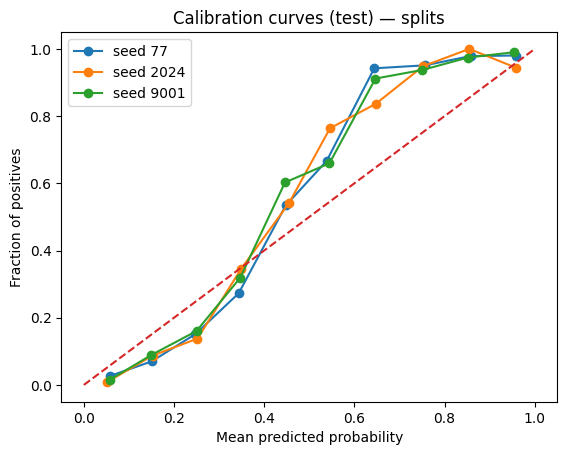

Saved: ../../demonstrative_applications/case_demo_01/figures/case01/calibration_splits_20260125T182441Z.png


In [10]:
def plot_calibration_for(strategy: str, seeds, n_bins: int = 10):
    if not seeds:
        print(f"No seeds for strategy={strategy}")
        return
    plt.figure()
    for seed in seeds:
        row = summary[(summary["strategy"] == strategy) & (summary["seed"] == seed)]
        if row.empty:
            continue
        schema_path = row.iloc[0]["schema_path"]
        preds = load_preds(schema_path, split="test")
        ensure_columns(preds, ["y_true", "y_prob"], "preds_test")
        y_true = preds["y_true"].to_numpy()
        y_prob = preds["y_prob"].to_numpy()
        frac_pos, mean_pred = calibration_curve(y_true, y_prob, n_bins=n_bins, strategy="uniform")
        plt.plot(mean_pred, frac_pos, marker="o", label=f"seed {seed}")

    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("Mean predicted probability")
    plt.ylabel("Fraction of positives")
    plt.title(f"Calibration curves (test) — {strategy}")
    plt.legend()
    fig_path = FIG_DIR / f"calibration_{strategy}_{RUN_ID}.png"
    plt.savefig(fig_path, dpi=300, bbox_inches="tight")
    plt.show()
    print("Saved:", fig_path)

for strat, seeds in repr_seeds.items():
    plot_calibration_for(strat, seeds, n_bins=10)

## 4) Error instability across seeds

In [11]:
from collections import defaultdict

errors = defaultdict(dict)  # errors[strategy][seed] = set(dataset_index)

for _, r in summary.iterrows():
    strat = r["strategy"]
    seed = int(r["seed"])
    preds = load_preds(r["schema_path"], split="test")
    ensure_columns(preds, ["dataset_index", "y_true", "y_pred"], "preds_test")
    wrong = preds[preds["y_true"].astype(int) != preds["y_pred"].astype(int)]
    errors[strat][seed] = set(wrong["dataset_index"].astype(int).to_list())

{strat: len(seeds) for strat, seeds in errors.items()}

{'splits': 10}

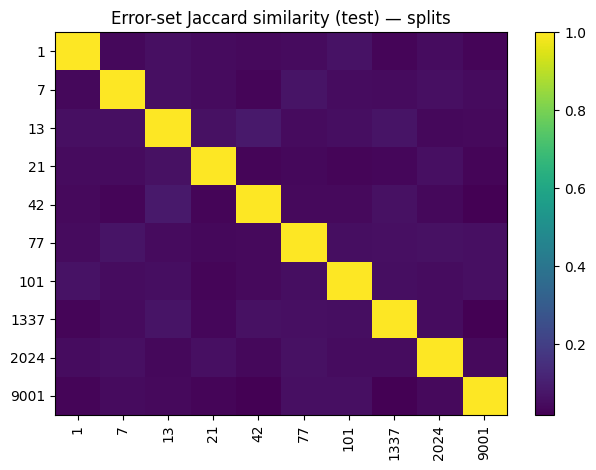

Saved: ../../demonstrative_applications/case_demo_01/figures/case01/error_jaccard_splits_20260125T182441Z.png
Saved: ../../demonstrative_applications/case_demo_01/tables/case01/error_jaccard_splits_20260125T182441Z.csv


In [12]:
def jaccard(a, b) -> float:
    a = set(a); b = set(b)
    if not a and not b:
        return 1.0
    inter = len(a.intersection(b))
    union = len(a.union(b))
    return inter / union if union else 0.0

def plot_jaccard_heatmap(strategy: str):
    seeds = sorted(errors[strategy].keys())
    if len(seeds) < 2:
        print(f"Need >=2 seeds for strategy={strategy}")
        return None
    mat = np.zeros((len(seeds), len(seeds)), dtype=float)
    for i, si in enumerate(seeds):
        for j, sj in enumerate(seeds):
            mat[i, j] = jaccard(errors[strategy][si], errors[strategy][sj])

    plt.figure()
    plt.imshow(mat, aspect="auto")
    plt.colorbar()
    plt.xticks(range(len(seeds)), seeds, rotation=90)
    plt.yticks(range(len(seeds)), seeds)
    plt.title(f"Error-set Jaccard similarity (test) — {strategy}")
    plt.tight_layout()
    fig_path = FIG_DIR / f"error_jaccard_{strategy}_{RUN_ID}.png"
    plt.savefig(fig_path, dpi=300, bbox_inches="tight")
    plt.show()
    print("Saved:", fig_path)

    df_mat = pd.DataFrame(mat, index=seeds, columns=seeds)
    out = TAB_DIR / f"error_jaccard_{strategy}_{RUN_ID}.csv"
    df_mat.to_csv(out)
    print("Saved:", out)
    return df_mat

for strat in errors.keys():
    plot_jaccard_heatmap(strat)

## 5) Fragility summary statement (auto-generated text)

In [13]:
def fragility_stats(df: pd.DataFrame, metric: str) -> pd.DataFrame:
    rows = []
    for strat, g in df.groupby("strategy"):
        vals = g[metric].to_numpy(dtype=float)
        rows.append({
            "strategy": strat,
            "metric": metric,
            "n": int(len(vals)),
            "mean": float(np.nanmean(vals)),
            "std": float(np.nanstd(vals)),
            "min": float(np.nanmin(vals)),
            "max": float(np.nanmax(vals)),
            "range": float(np.nanmax(vals) - np.nanmin(vals)),
            "cv": float(np.nanstd(vals) / np.nanmean(vals)) if float(np.nanmean(vals)) != 0.0 else np.nan,
        })
    return pd.DataFrame(rows)

frag = pd.concat([fragility_stats(summary, m) for m in ["test_auprc", "test_auroc"]], ignore_index=True)
display(frag)

frag_out = TAB_DIR / f"fragility_stats_{RUN_ID}.csv"
frag.to_csv(frag_out, index=False)
print("Saved:", frag_out)

for _, row in frag.iterrows():
    print(
        f"- {row['strategy']} {row['metric']}: mean={row['mean']:.3f}, std={row['std']:.3f}, "
        f"range=[{row['min']:.3f}, {row['max']:.3f}] (Δ={row['range']:.3f})."
    )

,strategy,metric,n,mean,std,min,max,range,cv
0,splits,test_auprc,20,0.896539,0.013220,0.863381,0.918419,0.055039,0.014746
1,splits,test_auroc,20,0.917155,0.009132,0.899197,0.933223,0.034026,0.009957


Saved: ../../demonstrative_applications/case_demo_01/tables/case01/fragility_stats_20260125T182441Z.csv
- splits test_auprc: mean=0.897, std=0.013, range=[0.863, 0.918] (Δ=0.055).
- splits test_auroc: mean=0.917, std=0.009, range=[0.899, 0.933] (Δ=0.034).
